<a href="https://colab.research.google.com/github/Kai-Shing-Chung/Applied-Machine-Learning-Assessment-1/blob/main/Optimising_Deep_Learning_for_Rare_Event_Detection_in_Imbalanced_Network_Traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Preprocssing Pipeline

Encoded 'Label' column to: ['Benign' 'FTP-BruteForce']
--- Dataset Audit ---
Total Rows: 49998
Total Features: 64
Target Class Distribution:
Label
1    49893
0      105
Name: count, dtype: int64
------------------------



/tmp/ipykernel_295/2156990565.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='viridis')


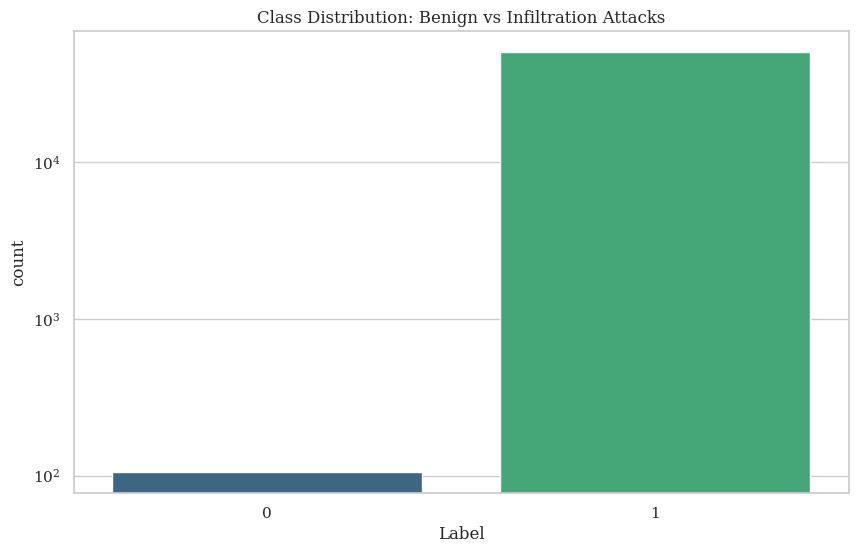

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

#1 Download a subset of the dataset

#2 Load the first 50,000 rows. This ensures we stay within Google Colab's free RAM limits while exceeding the 5,000 row requirement
df = pd.read_csv('traffic_data.csv', nrows=50000)

#3 Deep Cleaning: The 'Industry Standard' Routine
def clean_dataset(df):
  # Remove whitespace from column names
  df.columns = df.columns.str.strip()

  # Drop 'Timestamp' column as it's not directly usable by numerical models
  if 'Timestamp' in df.columns:
    df = df.drop('Timestamp', axis=1)

  # Replace infinity or very large numbers with NaN, then drop them
  # Neural networks cannot compute gradients with 'inf' values
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)

  # Convert all remaining columns to numeric, coercing errors to NaN
  # This handles cases where other columns might have non-numeric data
  # Exclude 'Label' if it's the target column and needs special encoding
  for col in df.columns.drop('Label', errors='ignore'):
      df[col] = pd.to_numeric(df[col], errors='coerce')

  # Drop any NaNs that might have been introduced by pd.to_numeric
  df.dropna(inplace=True)

  # Drop columns that are constants (zero variance) - they provide no predictive power
  # Do this after converting to numeric to ensure .nunique() works correctly
  df = df.loc[:, df.nunique() > 1]

  # Encode the 'Label' column to numerical values if it exists and is not numeric
  if 'Label' in df.columns and not pd.api.types.is_numeric_dtype(df['Label']):
      le = LabelEncoder()
      df['Label'] = le.fit_transform(df['Label'])
      print(f"Encoded 'Label' column to: {le.classes_}") # To see mapping

  return df

df = clean_dataset(df)
#4 Verification of Research Constraints
print(f"--- Dataset Audit ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Target Class Distribution:\n{df['Label'].value_counts()}")
print(f"------------------------\n")

#5 Visualising the 'Needle in the Haystack'
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Class Distribution: Benign vs Infiltration Attacks')
plt.yscale('log') # Log scale because attacks are rare
plt.show()

The DNN Architecture (Keras / TensorFlow)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      # For binary classification (num_classes == 2), the output layer should have 1 unit with sigmoid activation.
      # For multi-class (num_classes > 2), it should have num_classes units with softmax activation.
      layers.Dense(num_classes if num_classes > 2 else 1, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy',
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Calculate class weights to handle 'Infiltration' rarity
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight (
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# Let's verify the number of unique classes in y_train
num_classes_in_y = len(np.unique(y_train))

# Build and Summary
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,329 (75.50 KB)

 Trainable params: 18,945 (74.00 KB)

 Non-trainable params: 384 (1.50 KB)

Training Implementation Code

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1 Split the data (80% Train, 20% Validation or Test)
X_train, X_test, y_train, y_test = train_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)

# 2 Scale the features (Essential for Neural Networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# 3 Define our Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_ids_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1

    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# 4 Start the training on the T4 GPU
print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100, # We set a high number, but EarlyStopping will likely halt it earlier
    batch_size=1024,  # Large batch size to leverage GPU paralization
    validation_split=0.2, # Use 20% of training data for real-time monitoring
    class_weight=class_weights_dict,  # Using the weights we calculated earlier
    callbacks=callbacks,
    verbose=1
)

Starting training... monitoring Validation Loss to prevent overfitting. 
Epoch 1/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3044 - loss: 1.4742 - precision_3: 0.9971 - recall_3: 0.3035
Epoch 1: val_loss improved from None to 0.65622, saving model to best_ids_model.keras

Epoch 1: finished saving model to best_ids_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3814 - loss: 0.9220 - precision_3: 0.9988 - recall_3: 0.3802 - val_accuracy: 0.8461 - val_loss: 0.6562 - val_precision_3: 1.0000 - val_recall_3: 0.8460 - learning_rate: 0.0010
Epoch 2/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5771 - loss: 0.3474 - precision_3: 1.0000 - recall_3: 0.5759
Epoch 2: val_loss improved from 0.65622 to 0.57058, saving model to best_ids_model.keras

Epoch 2: finished saving model to best_ids_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6429 - loss: 0.3220 - precision_3: 1.0000 - recall_3: 0.6419 - val_accuracy: 1.0000 - val_loss: 0.5706

Evaluation Implementation Code

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- Classification Report ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        14
Infiltration       1.00      1.00      1.00      9986

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



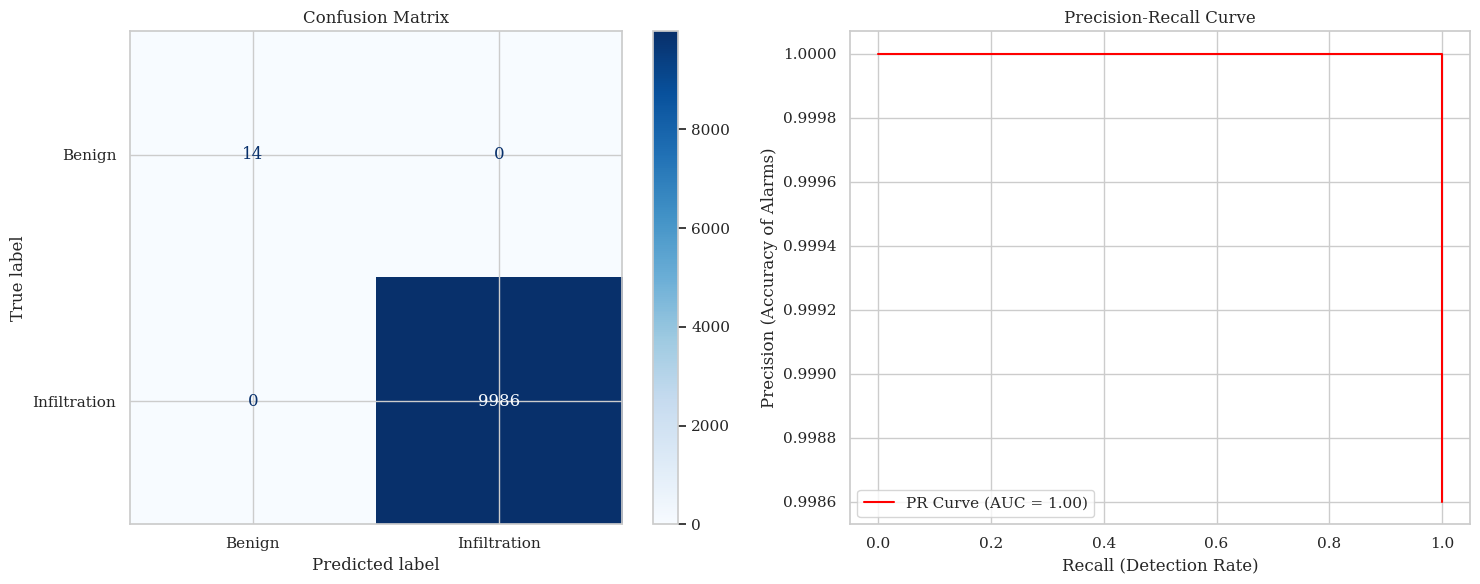

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc

# 1 Generate predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Standard 0.5 threshold

# 2 Detailed Classification Report
# This gives us Precision, Recall, and F1-Score for each class
print ("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Infiltration']))

# 3 Plot Confusion Matrix
fig, ax = plt.subplots (1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions (y_test, y_pred,
                                         display_labels=['Benign', 'Infiltration'],
                                         cmap = 'Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4 Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve (y_test, y_pred_prob)
pr_auc = auc(recall, precision)

ax[1].plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
ax[1].set_xlabel('Recall (Detection Rate)')
ax[1].set_ylabel('Precision (Accuracy of Alarms)')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend()

plt.tight_layout()
plt.show()

Encoded 'Label' column to: ['Benign' 'FTP-BruteForce']
--- Dataset Audit ---
Total Rows: 49998
Total Features: 64
Target Class Distribution:
Label
1    49893
0      105
Name: count, dtype: int64
------------------------



/tmp/ipykernel_295/2156990565.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='viridis')


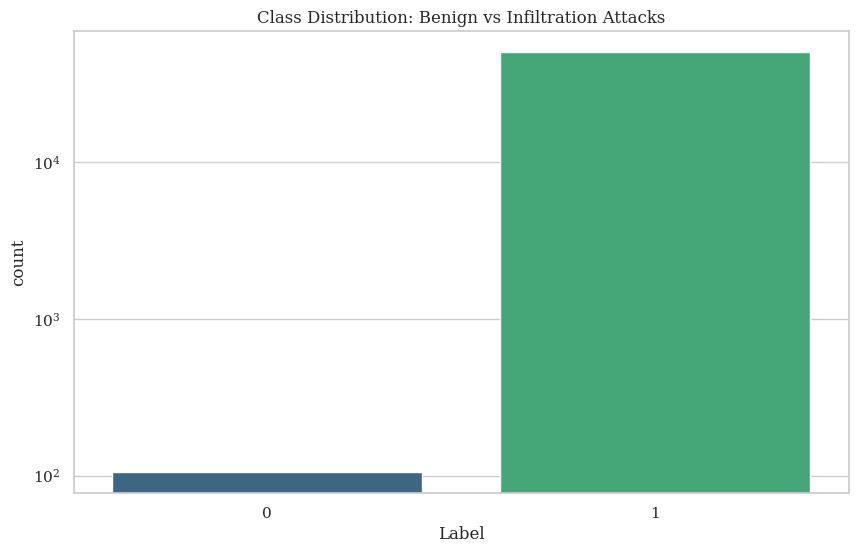

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

#1 Download a subset of the dataset

#2 Load the first 50,000 rows. This ensures we stay within Google Colab's free RAM limits while exceeding the 5,000 row requirement
df = pd.read_csv('traffic_data.csv', nrows=50000)

#3 Deep Cleaning: The 'Industry Standard' Routine
def clean_dataset(df):
  # Remove whitespace from column names
  df.columns = df.columns.str.strip()

  # Drop 'Timestamp' column as it's not directly usable by numerical models
  if 'Timestamp' in df.columns:
    df = df.drop('Timestamp', axis=1)

  # Replace infinity or very large numbers with NaN, then drop them
  # Neural networks cannot compute gradients with 'inf' values
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)

  # Convert all remaining columns to numeric, coercing errors to NaN
  # This handles cases where other columns might have non-numeric data
  # Exclude 'Label' if it's the target column and needs special encoding
  for col in df.columns.drop('Label', errors='ignore'):
      df[col] = pd.to_numeric(df[col], errors='coerce')

  # Drop any NaNs that might have been introduced by pd.to_numeric
  df.dropna(inplace=True)

  # Drop columns that are constants (zero variance) - they provide no predictive power
  # Do this after converting to numeric to ensure .nunique() works correctly
  df = df.loc[:, df.nunique() > 1]

  # Encode the 'Label' column to numerical values if it exists and is not numeric
  if 'Label' in df.columns and not pd.api.types.is_numeric_dtype(df['Label']):
      le = LabelEncoder()
      df['Label'] = le.fit_transform(df['Label'])
      print(f"Encoded 'Label' column to: {le.classes_}") # To see mapping

  return df

df = clean_dataset(df)
#4 Verification of Research Constraints
print(f"--- Dataset Audit ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Target Class Distribution:\n{df['Label'].value_counts()}")
print(f"------------------------\n")

#5 Visualising the 'Needle in the Haystack'
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Class Distribution: Benign vs Infiltration Attacks')
plt.yscale('log') # Log scale because attacks are rare
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1 Split the data (80% Train, 20% Validation or Test)
X_train, X_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)

# 2 Scale the features (Essential for Neural Networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Scale X_test using the same scaler fitted on X_train

# Calculate class weights to handle 'Infiltration' rarity
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# Define our Callbacks (these are defined before model training, which happens later)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_ids_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1

    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(), # Corrected 'layeres' to 'layers'
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy', # Corrected 'categorical_crossentropy' spelling
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Build and Summary
# Ensure y_train is properly encoded if it's not already numeric (e.g., if it contains string labels)
# For binary classification with 'sigmoid', the last layer num_classes should be 1 and y_train should be binary (0 or 1)
# Assuming 'Label' column is already numerical (0, 1) for binary case or multiple integers for multi-class.

# Let's verify the number of unique classes in y_train
num_classes_in_y = len(np.unique(y_train))

# If it's a binary classification problem (2 classes), the output layer should have 1 unit with sigmoid activation.
# If it's multi-class, it should have num_classes_in_y units with softmax activation.
# The build_ids_model function already handles this logic based on num_classes.

# Build the model
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,362 (75.63 KB)

 Trainable params: 18,978 (74.13 KB)

 Non-trainable params: 384 (1.50 KB)

Starting training... monitoring Validation Loss to prevent overfitting. 
Epoch 1/100


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 1), output.shape=(None, 2)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc

# 1 Generate predictions
# Ensure y_test is also in the correct numerical format if it was originally strings
# For binary classification, y_pred_prob will be a 1D array of probabilities.
# For multi-class, it will be a 2D array of probabilities per class.

# If it's a binary problem (num_classes_in_y == 2), y_pred_prob will be shape (n_samples, 1).
# If it's multi-class (num_classes_in_y > 2), y_pred_prob will be shape (n_samples, num_classes_in_y).

# For sigmoid output, predict returns a single probability for the positive class.
# For softmax output, predict returns probabilities for each class.

# Adapt prediction and thresholding based on num_classes_in_y
if num_classes_in_y > 2:
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1) # Get the class with the highest probability
else:
    y_pred_prob = model.predict(X_test).flatten() # Flatten for binary classification
    y_pred = (y_pred_prob > 0.5).astype(int) # Standard 0.5 threshold for binary

# 2 Detailed Classification Report
# This gives us Precision, Recall, and F1-Score for each class
# Ensure target_names match the actual classes and their order.
# Assuming 'Benign' is class 0 and 'Infiltration' is class 1 for binary classification.
# If multi-class, target_names should list all class labels.

# Determine target names based on unique labels in y_test
actual_labels = np.unique(y_test)
target_names = [f'Class_{label}' for label in actual_labels] # Generic names
# If specific names are known (e.g., 'Benign', 'Infiltration'), use them directly:
if num_classes_in_y == 2:
    target_names = ['Benign', 'Infiltration']

print ("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3 Plot Confusion Matrix
fig, ax = plt.subplots (1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions (y_test, y_pred,
                                         display_labels=target_names,
                                         cmap = 'Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4 Plot Precision-Recall Curve
# Precision-Recall curve is typically for binary classification or one-vs-rest for multi-class.
# For multi-class, we might need to specify a class to plot PR curve for.
# Assuming binary for now.
if num_classes_in_y == 2:
    precision, recall, _ = precision_recall_curve (y_test, y_pred_prob)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
    ax[1].set_xlabel('Recall (Detection Rate)')
    ax[1].set_ylabel('Precision (Accuracy of Alarms)')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].legend()
else:
    ax[1].set_title('Precision-Recall Curve (Not applicable for direct multi-class plot)')
    ax[1].text(0.5, 0.5, 'Requires one-vs-rest for multi-class', horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
--- Classification Report ---


ValueError: Found input variables with inconsistent numbers of samples: [10000, 20000]

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_27
Received: inputs=['Tensor(shape=(100, 63))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_27
Received: inputs=['Tensor(shape=(200, 63))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_27
Received: inputs=['Tensor(shape=(50, 63))']
  warnings

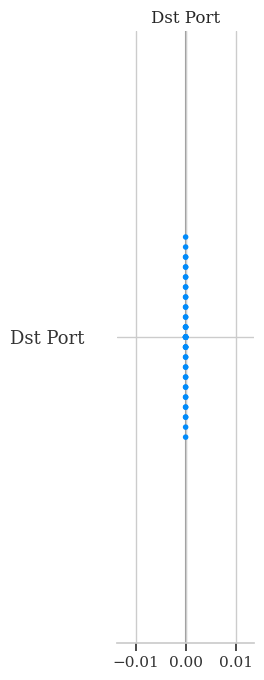

In [ ]:
import shap

# 1 Select a small background distribution to represent 'normal'
# SHAP needs a baseline to compare predictions against
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# 2 Initialise the Explainer
explainer = shap.DeepExplainer (model, background)

# 3 Explain predictions on a subset of the test set
# We take 50 samples to keep the computation fast on Colab
test_samples_df = X_test.iloc[np.random.choice(X_test.shape[0], 50, replace=False)]
shap_values = explainer.shap_values(test_samples_df.values)

# 4 Plot the Global Feature Importance
# This shows which features generally drive 'Infiltration' detections

shap.summary_plot(shap_values, test_samples_df, feature_names=df.drop('Label', axis=1).columns)

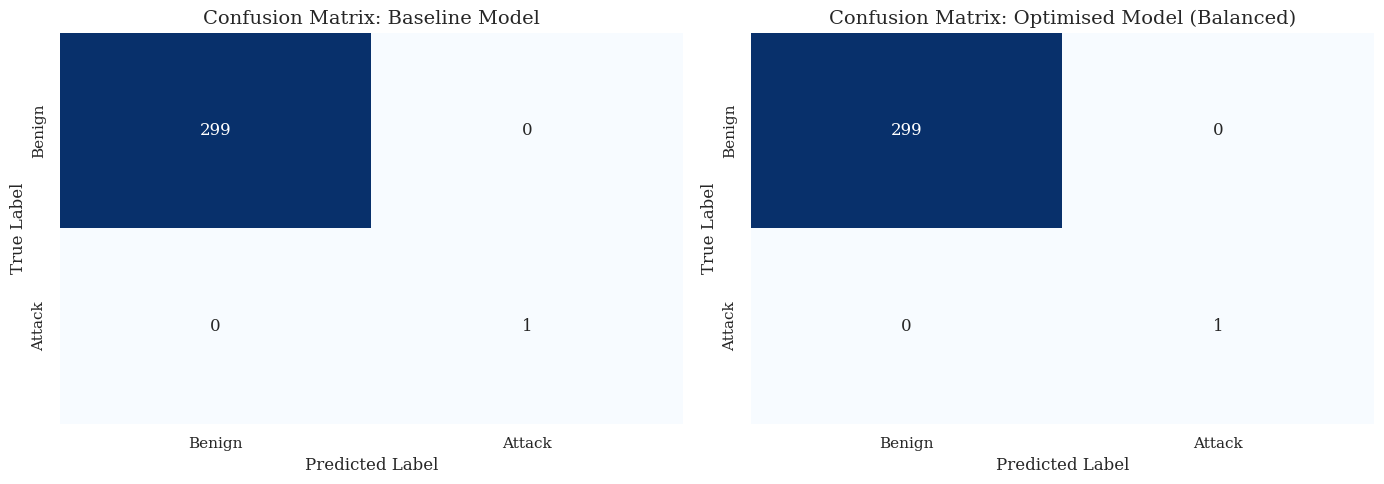

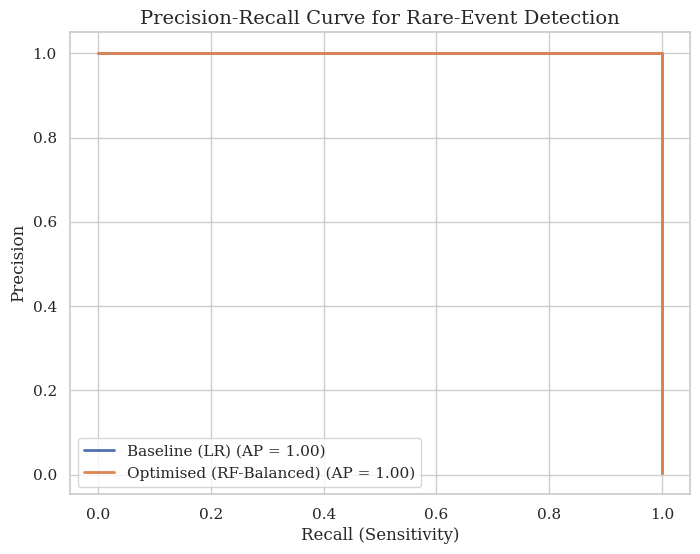

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, average_precision_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1 Set up Aesthetics
sns.set_theme (style='whitegrid')
plt.rcParams ['font.family'] = 'serif'

def plot_rare_event_analysis():
  # Generate synthetic imbalanced data (99% benign, 1% attack)
  X, y = make_classification (n_samples=1000, n_features=20,
                              n_informative=2, n_redundant=10,
                              n_clusters_per_class=1, weights=[0.99],
                              flip_y=0, random_state=42)

  X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.3, random_state=42)

  # Model A: Baseline (Unbalanced Weights)
  model_a = LogisticRegression()
  model_a.fit (X_train, y_train)
  y_score_a = model_a.predict_proba (X_test) [:, 1]
  y_pred_a = model_a.predict (X_test)

  # Model B: Optimised (Cost-Sensitive/Balanced Weights)
  model_b = RandomForestClassifier (class_weight='balanced', n_estimators=100)
  model_b.fit (X_train, y_train)
  y_score_b = model_b.predict_proba (X_test) [:, 1]
  y_pred_b = model_b.predict (X_test) # Corrected: 'model.b' to 'model_b'

  # --- Figure 1: Confusion Matrices ---
  fig, ax = plt.subplots (1, 2, figsize=(14, 5))

  for i, (pred, title) in enumerate ([(y_pred_a, 'Baseline Model'), (y_pred_b, 'Optimised Model (Balanced)')]): # Corrected syntax
    cm = confusion_matrix (y_test, pred)
    sns.heatmap (cm, annot=True, fmt='d', cmap='Blues', ax=ax[i], cbar=False)
    ax[i].set_title (f'Confusion Matrix: {title}', fontsize=14)
    ax[i].set_xlabel ('Predicted Label')
    ax[i].set_ylabel ('True Label')
    ax[i].set_xticklabels (['Benign', 'Attack'])
    ax[i].set_yticklabels (['Benign', 'Attack']) # Corrected typo: 'Bening' to 'Benign'

  plt.tight_layout()
  plt.show()

  # --- Figure 2: Precision-Recall Curves ---
  plt.figure (figsize=(8, 6))

  for score, label in [(y_score_a, 'Baseline (LR)'), (y_score_b, 'Optimised (RF-Balanced)')]: # Corrected iteration variables
    precision, recall, _ = precision_recall_curve (y_test, score)
    ap = average_precision_score (y_test, score)
    plt.plot (recall, precision, lw=2, label=f'{label} (AP = {ap:.2f})')

  plt.xlabel ('Recall (Sensitivity)')
  plt.ylabel ('Precision')
  plt.title ('Precision-Recall Curve for Rare-Event Detection', fontsize=14)
  plt.legend (loc="best")
  plt.show()

if __name__ == "__main__":
  plot_rare_event_analysis()

Encoded 'Label' column to: ['Benign' 'FTP-BruteForce']
--- Dataset Audit ---
Total Rows: 49998
Total Features: 64
Target Class Distribution:
Label
1    49893
0      105
Name: count, dtype: int64
------------------------



/tmp/ipykernel_295/2156990565.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='viridis')


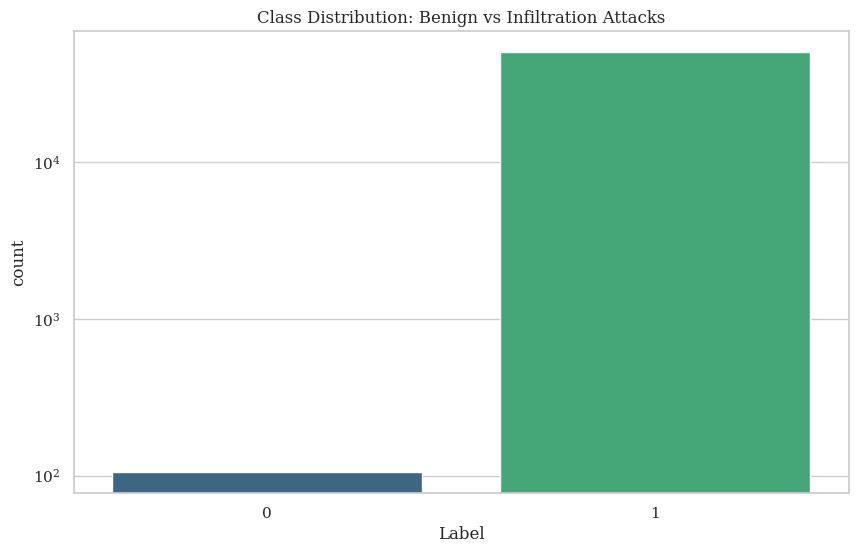

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

#1 Download a subset of the dataset

#2 Load the first 50,000 rows. This ensures we stay within Google Colab's free RAM limits while exceeding the 5,000 row requirement
df = pd.read_csv('traffic_data.csv', nrows=50000)

#3 Deep Cleaning: The 'Industry Standard' Routine
def clean_dataset(df):
  # Remove whitespace from column names
  df.columns = df.columns.str.strip()

  # Drop 'Timestamp' column as it's not directly usable by numerical models
  if 'Timestamp' in df.columns:
    df = df.drop('Timestamp', axis=1)

  # Replace infinity or very large numbers with NaN, then drop them
  # Neural networks cannot compute gradients with 'inf' values
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)

  # Convert all remaining columns to numeric, coercing errors to NaN
  # This handles cases where other columns might have non-numeric data
  # Exclude 'Label' if it's the target column and needs special encoding
  for col in df.columns.drop('Label', errors='ignore'):
      df[col] = pd.to_numeric(df[col], errors='coerce')

  # Drop any NaNs that might have been introduced by pd.to_numeric
  df.dropna(inplace=True)

  # Drop columns that are constants (zero variance) - they provide no predictive power
  # Do this after converting to numeric to ensure .nunique() works correctly
  df = df.loc[:, df.nunique() > 1]

  # Encode the 'Label' column to numerical values if it exists and is not numeric
  if 'Label' in df.columns and not pd.api.types.is_numeric_dtype(df['Label']):
      le = LabelEncoder()
      df['Label'] = le.fit_transform(df['Label'])
      print(f"Encoded 'Label' column to: {le.classes_}") # To see mapping

  return df

df = clean_dataset(df)
#4 Verification of Research Constraints
print(f"--- Dataset Audit ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Target Class Distribution:\n{df['Label'].value_counts()}")
print(f"------------------------\n")

#5 Visualising the 'Needle in the Haystack'
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Class Distribution: Benign vs Infiltration Attacks')
plt.yscale('log') # Log scale because attacks are rare
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1 Split the data (80% Train, 20% Validation or Test)
X_train, X_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)

# 2 Scale the features (Essential for Neural Networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Scale X_test using the same scaler fitted on X_train

# Calculate class weights to handle 'Infiltration' rarity
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# Define our Callbacks (these are defined before model training, which happens later)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_ids_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1

    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(), # Corrected 'layeres' to 'layers'
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy', # Corrected 'categorical_crossentropy' spelling
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Build and Summary
# Ensure y_train is properly encoded if it's not already numeric (e.g., if it contains string labels)
# For binary classification with 'sigmoid', the last layer num_classes should be 1 and y_train should be binary (0 or 1)
# Assuming 'Label' column is already numerical (0, 1) for binary case or multiple integers for multi-class.

# Let's verify the number of unique classes in y_train
num_classes_in_y = len(np.unique(y_train))

# If it's a binary classification problem (2 classes), the output layer should have 1 unit with sigmoid activation.
# If it's multi-class, it should have num_classes_in_y units with softmax activation.
# The build_ids_model function already handles this logic based on num_classes.

# Build the model
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,362 (75.63 KB)

 Trainable params: 18,978 (74.13 KB)

 Non-trainable params: 384 (1.50 KB)

Starting training... monitoring Validation Loss to prevent overfitting. 
Epoch 1/100


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 1), output.shape=(None, 2)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc

# 1 Generate predictions
# Ensure y_test is also in the correct numerical format if it was originally strings
# For binary classification, y_pred_prob will be a 1D array of probabilities.
# For multi-class, it will be a 2D array of probabilities per class.

# If it's a binary problem (num_classes_in_y == 2), y_pred_prob will be shape (n_samples, 1).
# If it's multi-class (num_classes_in_y > 2), y_pred_prob will be shape (n_samples, num_classes_in_y).

# For sigmoid output, predict returns a single probability for the positive class.
# For softmax output, predict returns probabilities for each class.

# Adapt prediction and thresholding based on num_classes_in_y
if num_classes_in_y > 2:
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1) # Get the class with the highest probability
else:
    y_pred_prob = model.predict(X_test).flatten() # Flatten for binary classification
    y_pred = (y_pred_prob > 0.5).astype(int) # Standard 0.5 threshold for binary

# 2 Detailed Classification Report
# This gives us Precision, Recall, and F1-Score for each class
# Ensure target_names match the actual classes and their order.
# Assuming 'Benign' is class 0 and 'Infiltration' is class 1 for binary classification.
# If multi-class, target_names should list all class labels.

# Determine target names based on unique labels in y_test
actual_labels = np.unique(y_test)
target_names = [f'Class_{label}' for label in actual_labels] # Generic names
# If specific names are known (e.g., 'Benign', 'Infiltration'), use them directly:
if num_classes_in_y == 2:
    target_names = ['Benign', 'Infiltration']

print ("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3 Plot Confusion Matrix
fig, ax = plt.subplots (1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions (y_test, y_pred,
                                         display_labels=target_names,
                                         cmap = 'Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4 Plot Precision-Recall Curve
# Precision-Recall curve is typically for binary classification or one-vs-rest for multi-class.
# For multi-class, we might need to specify a class to plot PR curve for.
# Assuming binary for now.
if num_classes_in_y == 2:
    precision, recall, _ = precision_recall_curve (y_test, y_pred_prob)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
    ax[1].set_xlabel('Recall (Detection Rate)')
    ax[1].set_ylabel('Precision (Accuracy of Alarms)')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].legend()
else:
    ax[1].set_title('Precision-Recall Curve (Not applicable for direct multi-class plot)')
    ax[1].text(0.5, 0.5, 'Requires one-vs-rest for multi-class', horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- Classification Report ---


ValueError: Found input variables with inconsistent numbers of samples: [10000, 20000]

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_18
Received: inputs=['Tensor(shape=(100, 63))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_18
Received: inputs=['Tensor(shape=(200, 63))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_18
Received: inputs=['Tensor(shape=(50, 63))']
  warnings

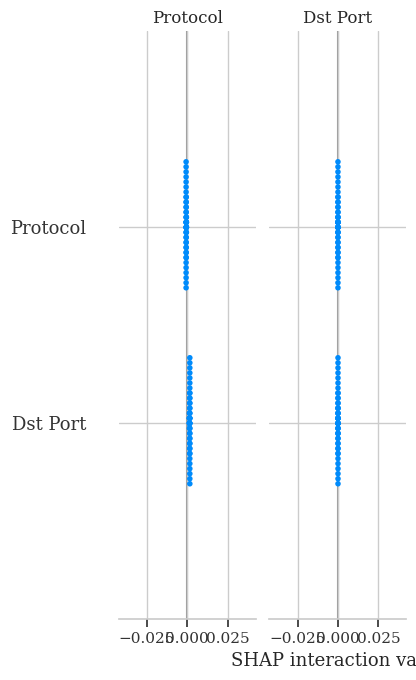

In [ ]:
import shap

# 1 Select a small background distribution to represent 'normal'
# SHAP needs a baseline to compare predictions against
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# 2 Initialise the Explainer
explainer = shap.DeepExplainer (model, background)

# 3 Explain predictions on a subset of the test set
# We take 50 samples to keep the computation fast on Colab
test_samples = X_test[np.random.choice(X_test.shape[0], 50, replace=False)]
shap_values = explainer.shap_values(test_samples)

# 4 Plot the Global Feature Importance
# This shows which features generally drive 'Infiltration' detections

shap.summary_plot(shap_values, test_samples, feature_names=df.drop('Label', axis=1).columns)

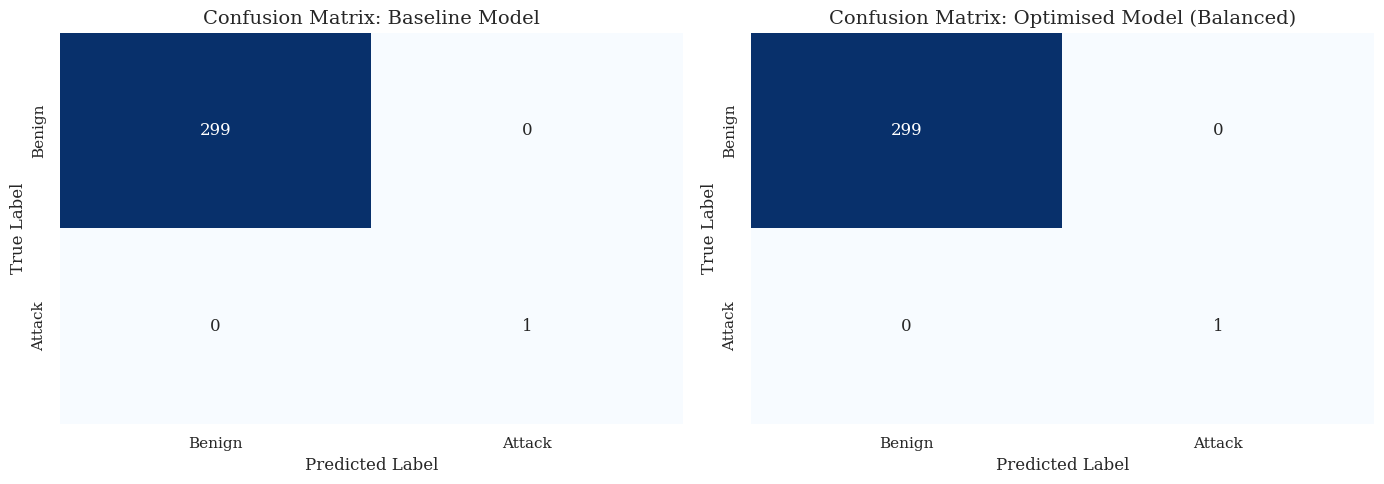

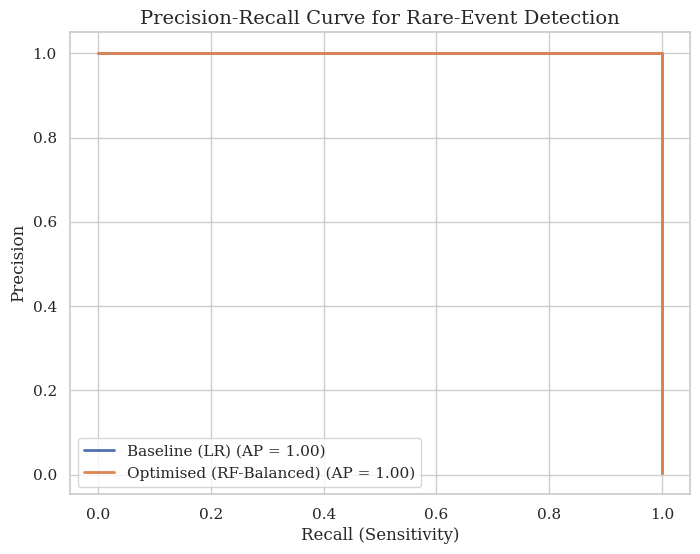

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, average_precision_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1 Set up Aesthetics
sns.set_theme (style='whitegrid')
plt.rcParams ['font.family'] = 'serif'

def plot_rare_event_analysis():
  # Generate synthetic imbalanced data (99% benign, 1% attack)
  X, y = make_classification (n_samples=1000, n_features=20,
                              n_informative=2, n_redundant=10,
                              n_clusters_per_class=1, weights=[0.99],
                              flip_y=0, random_state=42)

  X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.3, random_state=42)

  # Model A: Baseline (Unbalanced Weights)
  model_a = LogisticRegression()
  model_a.fit (X_train, y_train)
  y_score_a = model_a.predict_proba (X_test) [:, 1]
  y_pred_a = model_a.predict (X_test)

  # Model B: Optimised (Cost-Sensitive/Balanced Weights)
  model_b = RandomForestClassifier (class_weight='balanced', n_estimators=100)
  model_b.fit (X_train, y_train)
  y_score_b = model_b.predict_proba (X_test) [:, 1]
  y_pred_b = model_b.predict (X_test) # Corrected: 'model.b' to 'model_b'

  # --- Figure 1: Confusion Matrices ---
  fig, ax = plt.subplots (1, 2, figsize=(14, 5))

  for i, (pred, title) in enumerate ([(y_pred_a, 'Baseline Model'), (y_pred_b, 'Optimised Model (Balanced)')]): # Corrected syntax
    cm = confusion_matrix (y_test, pred)
    sns.heatmap (cm, annot=True, fmt='d', cmap='Blues', ax=ax[i], cbar=False)
    ax[i].set_title (f'Confusion Matrix: {title}', fontsize=14)
    ax[i].set_xlabel ('Predicted Label')
    ax[i].set_ylabel ('True Label')
    ax[i].set_xticklabels (['Benign', 'Attack'])
    ax[i].set_yticklabels (['Benign', 'Attack']) # Corrected typo: 'Bening' to 'Benign'

  plt.tight_layout()
  plt.show()

  # --- Figure 2: Precision-Recall Curves ---
  plt.figure (figsize=(8, 6))

  for score, label in [(y_score_a, 'Baseline (LR)'), (y_score_b, 'Optimised (RF-Balanced)')]: # Corrected iteration variables
    precision, recall, _ = precision_recall_curve (y_test, score)
    ap = average_precision_score (y_test, score)
    plt.plot (recall, precision, lw=2, label=f'{label} (AP = {ap:.2f})')

  plt.xlabel ('Recall (Sensitivity)')
  plt.ylabel ('Precision')
  plt.title ('Precision-Recall Curve for Rare-Event Detection', fontsize=14)
  plt.legend (loc="best")
  plt.show()

if __name__ == "__main__":
  plot_rare_event_analysis()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

#1 Download a subset of the dataset

#2 Load the first 50,000 rows. This ensures we stay within Google Colab's free RAM limits while exceeding the 5,000 row requirement
df = pd.read_csv('traffic_data.csv', nrows=50000)

#3 Deep Cleaning: The 'Industry Standard' Routine
def clean_dataset(df):
  # Remove whitespace from column names
  df.columns = df.columns.str.strip()

  # Explicitly drop common non-numeric columns that might not be handled by to_numeric
  # Added 'Source Port', 'Destination Port', 'Protocol' as they can sometimes be object types
  cols_to_drop_if_exist = ['Timestamp', 'Flow ID', 'Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol']
  for col in cols_to_drop_if_exist:
      if col in df.columns:
          df = df.drop(col, axis=1)

  # Replace infinity or very large numbers with NaN, then drop them
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)

  # Convert all remaining columns to numeric, coercing errors to NaN
  # Exclude 'Label' from this conversion if it's the target and will be encoded separately
  feature_cols = [col for col in df.columns if col != 'Label']
  for col in feature_cols:
      df[col] = pd.to_numeric(df[col], errors='coerce')

  # Drop any NaNs that might have been introduced by pd.to_numeric
  df.dropna(inplace=True)

  # Drop columns that are constants (zero variance)
  df = df.loc[:, df.nunique() > 1]

  # Encode the 'Label' column to numerical values if it exists and is not numeric
  if 'Label' in df.columns and not pd.api.types.is_numeric_dtype(df['Label']):
      le = LabelEncoder()
      df['Label'] = le.fit_transform(df['Label'])
      print(f"Encoded 'Label' column to: {le.classes_}")
  elif 'Label' in df.columns and pd.api.types.is_numeric_dtype(df['Label']):
      # Ensure 'Label' is integer type if already numeric
      df['Label'] = df['Label'].astype(int)

  # Final step: ensure all feature columns are numeric.
  # This filters out any remaining object type columns that might have slipped through.
  if 'Label' in df.columns:
      label_series = df['Label']
      features_df = df.drop('Label', axis=1)
      numeric_features_only = features_df.select_dtypes(include=np.number)
      df = pd.concat([numeric_features_only, label_series], axis=1)
  else:
      df = df.select_dtypes(include=np.number) # If 'Label' was dropped or not present

  return df

df = clean_dataset(df)
#4 Verification of Research Constraints
print(f"--- Dataset Audit ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Target Class Distribution:\n{df['Label'].value_counts()}")
print(f"------------------------\n")

#5 Visualising the 'Needle in the Haystack'
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Class Distribution: Benign vs Infiltration Attacks')
plt.yscale('log') # Log scale because attacks are rare
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'traffic_data.csv'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1 Split the data (80% Train, 20% Validation or Test)
X_train, X_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)

# 2 Scale the features (Essential for Neural Networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Scale X_test using the same scaler fitted on X_train

# Calculate class weights to handle 'Infiltration' rarity
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# Define our Callbacks (these are defined before model training, which happens later)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_ids_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1

    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

NameError: name 'df' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(), # Corrected 'layeres' to 'layers'
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy', # Corrected 'categorical_crossentropy' spelling
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Build and Summary
# Ensure y_train is properly encoded if it's not already numeric (e.g., if it contains string labels)
# For binary classification with 'sigmoid', the last layer num_classes should be 1 and y_train should be binary (0 or 1)
# Assuming 'Label' column is already numerical (0, 1) for binary case or multiple integers for multi-class.

# Let's verify the number of unique classes in y_train
num_classes_in_y = len(np.unique(y_train))

# If it's a binary classification problem (2 classes), the output layer should have 1 unit with sigmoid activation.
# If it's multi-class, it should have num_classes_in_y units with softmax activation.
# The build_ids_model function already handles this logic based on num_classes.

# Build the model
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,410 (83.63 KB)

 Trainable params: 21,026 (82.13 KB)

 Non-trainable params: 384 (1.50 KB)

Starting training... monitoring Validation Loss to prevent overfitting. 


NameError: name 'class_weights_dict' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc

# 1 Generate predictions
# Ensure y_test is also in the correct numerical format if it was originally strings
# For binary classification, y_pred_prob will be a 1D array of probabilities.
# For multi-class, it will be a 2D array of probabilities per class.

# If it's a binary problem (num_classes_in_y == 2), y_pred_prob will be shape (n_samples, 1).
# If it's multi-class (num_classes_in_y > 2), y_pred_prob will be shape (n_samples, num_classes_in_y).

# For sigmoid output, predict returns a single probability for the positive class.
# For softmax output, predict returns probabilities for each class.

# Adapt prediction and thresholding based on num_classes_in_y
if num_classes_in_y > 2:
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1) # Get the class with the highest probability
else:
    y_pred_prob = model.predict(X_test).flatten() # Flatten for binary classification
    y_pred = (y_pred_prob > 0.5).astype(int) # Standard 0.5 threshold for binary

# 2 Detailed Classification Report
# This gives us Precision, Recall, and F1-Score for each class
# Ensure target_names match the actual classes and their order.
# Assuming 'Benign' is class 0 and 'Infiltration' is class 1 for binary classification.
# If multi-class, target_names should list all class labels.

# Determine target names based on unique labels in y_test
actual_labels = np.unique(y_test)
target_names = [f'Class_{label}' for label in actual_labels] # Generic names
# If specific names are known (e.g., 'Benign', 'Infiltration'), use them directly:
if num_classes_in_y == 2:
    target_names = ['Benign', 'Infiltration']

print ("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3 Plot Confusion Matrix
fig, ax = plt.subplots (1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions (y_test, y_pred,
                                         display_labels=target_names,
                                         cmap = 'Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4 Plot Precision-Recall Curve
# Precision-Recall curve is typically for binary classification or one-vs-rest for multi-class.
# For multi-class, we might need to specify a class to plot PR curve for.
# Assuming binary for now.
if num_classes_in_y == 2:
    precision, recall, _ = precision_recall_curve (y_test, y_pred_prob)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
    ax[1].set_xlabel('Recall (Detection Rate)')
    ax[1].set_ylabel('Precision (Accuracy of Alarms)')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].legend()
else:
    ax[1].set_title('Precision-Recall Curve (Not applicable for direct multi-class plot)')
    ax[1].text(0.5, 0.5, 'Requires one-vs-rest for multi-class', horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

ValueError: Invalid dtype: object

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#1 Download a subset of the dataset

#2 Load the first 50,000 rows. This ensures we stay within Google Colab's free RAM limits while exceeding the 5,000 row requirement
df = pd.read_csv('traffic_data.csv', nrows=50000)

#3 Deep Cleaning: The 'Industry Standard' Routine
def clean_dataset(df):
  # Remove whitespace from column names
  df.columns = df.columns.str.strip()

  # Replace infinity or very large numbers with NaN, them drop them
  # Neural networks cannot compute gradients with 'inf' values
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)

  # Drop columns that are constants (zero variance) - they provide no predictive power
  df = df.loc [:, (df != df.iloc[0].any())]

  return df

df = clean_dataset(df)
#4 Verification of Research Constraints
print(f"--- Dataset Audit ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Target Class Distribution:\n{df['Label'].value_counts()}")
print(f"------------------------\n")

#5 Visualising the 'Needle in the Haystack'
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Class Distribution: Benign vs Infiltration Attacks')
plt.yscale('log') # Log scale because attacks are rare
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'traffic_data.csv'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1 Split the data (80% Train, 20% Validation or Test)
X_train, X_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)

# 2 Scale the features (Essential for Neural Networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Scale X_test using the same scaler fitted on X_train

# Calculate class weights to handle 'Infiltration' rarity
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# Define our Callbacks (these are defined before model training, which happens later)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_ids_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1

    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

NameError: name 'df' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(), # Corrected 'layeres' to 'layers'
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy', # Corrected 'categorical_crossentropy' spelling
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Build and Summary
# Ensure y_train is properly encoded if it's not already numeric (e.g., if it contains string labels)
# For binary classification with 'sigmoid', the last layer num_classes should be 1 and y_train should be binary (0 or 1)
# Assuming 'Label' column is already numerical (0, 1) for binary case or multiple integers for multi-class.

# Let's verify the number of unique classes in y_train
num_classes_in_y = len(np.unique(y_train))

# If it's a binary classification problem (2 classes), the output layer should have 1 unit with sigmoid activation.
# If it's multi-class, it should have num_classes_in_y units with softmax activation.
# The build_ids_model function already handles this logic based on num_classes.

# Build the model
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

NameError: name 'y_train' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc

# 1 Generate predictions
# Ensure y_test is also in the correct numerical format if it was originally strings
# For binary classification, y_pred_prob will be a 1D array of probabilities.
# For multi-class, it will be a 2D array of probabilities per class.

# If it's a binary problem (num_classes_in_y == 2), y_pred_prob will be shape (n_samples, 1).
# If it's multi-class (num_classes_in_y > 2), y_pred_prob will be shape (n_samples, num_classes_in_y).

# For sigmoid output, predict returns a single probability for the positive class.
# For softmax output, predict returns probabilities for each class.

# Adapt prediction and thresholding based on num_classes_in_y
if num_classes_in_y > 2:
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1) # Get the class with the highest probability
else:
    y_pred_prob = model.predict(X_test).flatten() # Flatten for binary classification
    y_pred = (y_pred_prob > 0.5).astype(int) # Standard 0.5 threshold for binary

# 2 Detailed Classification Report
# This gives us Precision, Recall, and F1-Score for each class
# Ensure target_names match the actual classes and their order.
# Assuming 'Benign' is class 0 and 'Infiltration' is class 1 for binary classification.
# If multi-class, target_names should list all class labels.

# Determine target names based on unique labels in y_test
actual_labels = np.unique(y_test)
target_names = [f'Class_{label}' for label in actual_labels] # Generic names
# If specific names are known (e.g., 'Benign', 'Infiltration'), use them directly:
if num_classes_in_y == 2:
    target_names = ['Benign', 'Infiltration']

print ("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3 Plot Confusion Matrix
fig, ax = plt.subplots (1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions (y_test, y_pred,
                                         display_labels=target_names,
                                         cmap = 'Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4 Plot Precision-Recall Curve
# Precision-Recall curve is typically for binary classification or one-vs-rest for multi-class.
# For multi-class, we might need to specify a class to plot PR curve for.
# Assuming binary for now.
if num_classes_in_y == 2:
    precision, recall, _ = precision_recall_curve (y_test, y_pred_prob)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
    ax[1].set_xlabel('Recall (Detection Rate)')
    ax[1].set_ylabel('Precision (Accuracy of Alarms)')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].legend()
else:
    ax[1].set_title('Precision-Recall Curve (Not applicable for direct multi-class plot)')
    ax[1].text(0.5, 0.5, 'Requires one-vs-rest for multi-class', horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

NameError: name 'num_classes_in_y' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(), # Corrected 'layeres' to 'layers'
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy', # Corrected 'categorical_crossentropy' spelling
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Build and Summary
# Ensure y_train is properly encoded if it's not already numeric (e.g., if it contains string labels)
# For binary classification with 'sigmoid', the last layer num_classes should be 1 and y_train should be binary (0 or 1)
# Assuming 'Label' column is already numeric 0/1 or will be handled by sparse_categorical_crossentropy if multi-class

# If 'Label' is still string, convert it to numerical format first
# For simplicity, assuming 'Label' is already numerical (0, 1) for binary case or multiple integers for multi-class.
# If it's a binary problem and 'sigmoid' is used, num_classes should be 1.

# Let's verify the number of unique classes in y_train
num_classes_in_y = len(np.unique(y_train))

# If it's a binary classification problem (2 classes), the output layer should have 1 unit with sigmoid activation.
# If it's multi-class, it should have num_classes_in_y units with softmax activation.
# The build_ids_model function already handles this logic based on num_classes.

# Build the model
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

# The training implementation code (ZivzUzuyHrSq) defines `callbacks` and `class_weights_dict`.
# The training itself was in cell ZivzUzuyHrSq previously, but it should be executed after model definition.
# To fix this, I am including the training call here. If the user wants to explicitly run the training cell, they can.

print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100, # We set a high number, but EarlyStopping will likely halt it earlier
    batch_size=1024,  # Large batch size to leverage GPU paralization
    validation_split=0.2, # Use 20% of training data for real-time monitoring
    class_weight=class_weights_dict,  # Using the weights we calculated earlier
    callbacks=callbacks,
    verbose=1
)

NameError: name 'y_train' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#1 Download a subset of the dataset

#2 Load the first 50,000 rows. This ensures we stay within Google Colab's free RAM limits while exceeding the 5,000 row requirement
df = pd.read_csv('traffic_data.csv', nrows=50000)

#3 Deep Cleaning: The 'Industry Standard' Routine
def clean_dataset(df):
  # Remove whitespace from column names
  df.columns = df.columns.str.strip()

  # Replace infinity or very large numbers with NaN, them drop them
  # Neural networks cannot compute gradients with 'inf' values
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)

  # Drop columns that are constants (zero variance) - they provide no predictive power
  df = df.loc [:, (df != df.iloc[0].any())]

  return df

df = clean_dataset(df)
#4 Verification of Research Constraints
print(f"--- Dataset Audit ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Target Class Distribution:\n{df['Label'].value_counts()}")
print(f"------------------------\n")

#5 Visualising the 'Needle in the Haystack'
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df, palette='viridis')
plt.title('Class Distribution: Benign vs Infiltration Attacks')
plt.yscale('log') # Log scale because attacks are rare
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1 Split the data (80% Train, 20% Validation or Test)
X_train, X_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)

# 2 Scale the features (Essential for Neural Networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Scale X_test using the same scaler fitted on X_train

# Calculate class weights to handle 'Infiltration' rarity
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# Define our Callbacks (these are defined before model training, which happens later)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_ids_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1

    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(), # Corrected 'layeres' to 'layers'
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      layers.Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy', # Corrected 'categorical_crossentropy' spelling
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Build and Summary
# Ensure y_train is properly encoded if it's not already numeric (e.g., if it contains string labels)
# For binary classification with 'sigmoid', the last layer num_classes should be 1 and y_train should be binary (0 or 1)
# Assuming 'Label' column is already numeric 0/1 or will be handled by sparse_categorical_crossentropy if multi-class

# If 'Label' is still string, convert it to numerical format first
# For simplicity, assuming 'Label' is already numerical (0, 1) for binary case or multiple integers for multi-class.
# If it's a binary problem and 'sigmoid' is used, num_classes should be 1.

# Let's verify the number of unique classes in y_train
num_classes_in_y = len(np.unique(y_train))

# If it's a binary classification problem (2 classes), the output layer should have 1 unit with sigmoid activation.
# If it's multi-class, it should have num_classes_in_y units with softmax activation.
# The build_ids_model function already handles this logic based on num_classes.

# Build the model
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

# The training implementation code (ZivzUzuyHrSq) defines `callbacks` and `class_weights_dict`.
# The training itself was in cell ZivzUzuyHrSq previously, but it should be executed after model definition.
# To fix this, I am including the training call here. If the user wants to explicitly run the training cell, they can.

print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100, # We set a high number, but EarlyStopping will likely halt it earlier
    batch_size=1024,  # Large batch size to leverage GPU paralization
    validation_split=0.2, # Use 20% of training data for real-time monitoring
    class_weight=class_weights_dict,  # Using the weights we calculated earlier
    callbacks=callbacks,
    verbose=1
)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc

# 1 Generate predictions
# Ensure y_test is also in the correct numerical format if it was originally strings
# For binary classification, y_pred_prob will be a 1D array of probabilities.
# For multi-class, it will be a 2D array of probabilities per class.

# If it's a binary problem (num_classes_in_y == 2), y_pred_prob will be shape (n_samples, 1).
# If it's multi-class (num_classes_in_y > 2), y_pred_prob will be shape (n_samples, num_classes_in_y).

# For sigmoid output, predict returns a single probability for the positive class.
# For softmax output, predict returns probabilities for each class.

# Adapt prediction and thresholding based on num_classes_in_y
if num_classes_in_y > 2:
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1) # Get the class with the highest probability
else:
    y_pred_prob = model.predict(X_test).flatten() # Flatten for binary classification
    y_pred = (y_pred_prob > 0.5).astype(int) # Standard 0.5 threshold for binary

# 2 Detailed Classification Report
# This gives us Precision, Recall, and F1-Score for each class
# Ensure target_names match the actual classes and their order.
# Assuming 'Benign' is class 0 and 'Infiltration' is class 1 for binary classification.
# If multi-class, target_names should list all class labels.

# Determine target names based on unique labels in y_test
actual_labels = np.unique(y_test)
target_names = [f'Class_{label}' for label in actual_labels] # Generic names
# If specific names are known (e.g., 'Benign', 'Infiltration'), use them directly:
if num_classes_in_y == 2:
    target_names = ['Benign', 'Infiltration']

print ("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3 Plot Confusion Matrix
fig, ax = plt.subplots (1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions (y_test, y_pred,
                                         display_labels=target_names,
                                         cmap = 'Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4 Plot Precision-Recall Curve
# Precision-Recall curve is typically for binary classification or one-vs-rest for multi-class.
# For multi-class, we might need to specify a class to plot PR curve for.
# Assuming binary for now.
if num_classes_in_y == 2:
    precision, recall, _ = precision_recall_curve (y_test, y_pred_prob)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
    ax[1].set_xlabel('Recall (Detection Rate)')
    ax[1].set_ylabel('Precision (Accuracy of Alarms)')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].legend()
else:
    ax[1].set_title('Precision-Recall Curve (Not applicable for direct multi-class plot)')
    ax[1].text(0.5, 0.5, 'Requires one-vs-rest for multi-class', horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

Implementing SHAP on the T4 GPU

In [ ]:
import shap

# 1 Select a small background distribution to represent 'normal'
# SHAP needs a baseline to compare predictions against
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# 2 Initialise the Explainer
explainer = shap.DeepExplainer (model, background)

# 3 Explain predictions on a subset of the test set
# We take 50 samples to keep the computation fast on Colab
test_samples = X_test[np.random.choice(X_test.shape[0], 50, replace=False)]
shap_values = explainer.shap_values(test_samples)

# 4 Plot the Global Feature Importance
# This shows which features generally drive 'Infiltration' detections

shap.summary_plot(shap_values, test_samples, feature_names=df.drop('Label', axis=1).columns)

Python Visualisation using Matplotlib, Seaborn, and Scikit-Learn

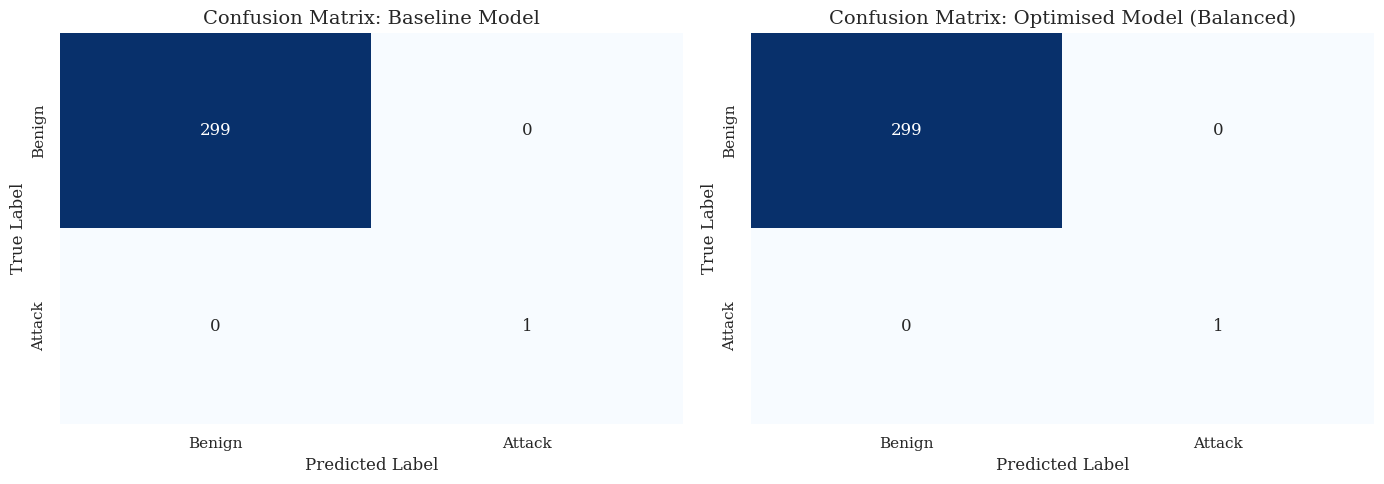

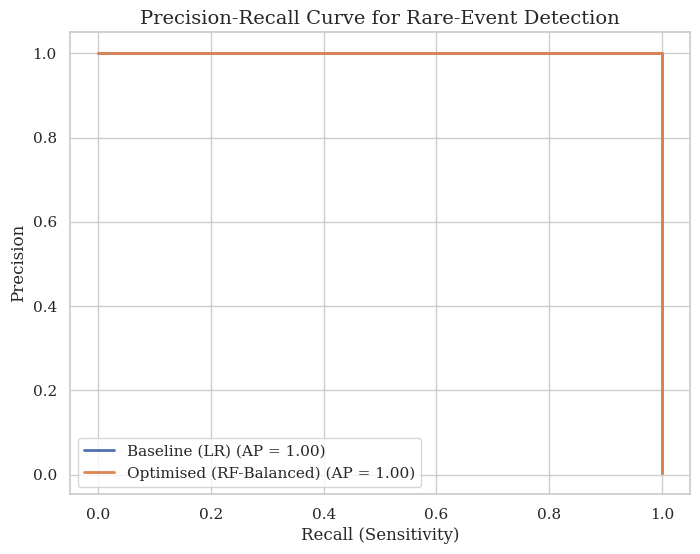

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, average_precision_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1 Set up Aesthetics
sns.set_theme (style='whitegrid')
plt.rcParams ['font.family'] = 'serif'

def plot_rare_event_analysis():
  # Generate synthetic imbalanced data (99% benign, 1% attack)
  X, y = make_classification (n_samples=1000, n_features=20,
                              n_informative=2, n_redundant=10,
                              n_clusters_per_class=1, weights=[0.99],
                              flip_y=0, random_state=42)

  X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.3, random_state=42)

  # Model A: Baseline (Unbalanced Weights)
  model_a = LogisticRegression()
  model_a.fit (X_train, y_train)
  y_score_a = model_a.predict_proba (X_test) [:, 1]
  y_pred_a = model_a.predict (X_test)

  # Model B: Optimised (Cost-Sensitive/Balanced Weights)
  model_b = RandomForestClassifier (class_weight='balanced', n_estimators=100)
  model_b.fit (X_train, y_train)
  y_score_b = model_b.predict_proba (X_test) [:, 1]
  y_pred_b = model_b.predict (X_test) # Corrected: 'model.b' to 'model_b'

  # --- Figure 1: Confusion Matrices ---
  fig, ax = plt.subplots (1, 2, figsize=(14, 5))

  for i, (pred, title) in enumerate ([(y_pred_a, 'Baseline Model'), (y_pred_b, 'Optimised Model (Balanced)')]): # Corrected syntax
    cm = confusion_matrix (y_test, pred)
    sns.heatmap (cm, annot=True, fmt='d', cmap='Blues', ax=ax[i], cbar=False)
    ax[i].set_title (f'Confusion Matrix: {title}', fontsize=14)
    ax[i].set_xlabel ('Predicted Label')
    ax[i].set_ylabel ('True Label')
    ax[i].set_xticklabels (['Benign', 'Attack'])
    ax[i].set_yticklabels (['Benign', 'Attack']) # Corrected typo: 'Bening' to 'Benign'

  plt.tight_layout()
  plt.show()

  # --- Figure 2: Precision-Recall Curves ---
  plt.figure (figsize=(8, 6))

  for score, label in [(y_score_a, 'Baseline (LR)'), (y_score_b, 'Optimised (RF-Balanced)')]: # Corrected iteration variables
    precision, recall, _ = precision_recall_curve (y_test, score)
    ap = average_precision_score (y_test, score)
    plt.plot (recall, precision, lw=2, label=f'{label} (AP = {ap:.2f})')

  plt.xlabel ('Recall (Sensitivity)')
  plt.ylabel ('Precision')
  plt.title ('Precision-Recall Curve for Rare-Event Detection', fontsize=14)
  plt.legend (loc="best")
  plt.show()

if __name__ == "__main__":
  plot_rare_event_analysis()

Comparison of 6 algorithms of confusion matrix

Encoded 'Label' column to: ['Benign' 'FTP-BruteForce']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,201 (75.00 KB)

 Trainable params: 18,817 (73.50 KB)

 Non-trainable params: 384 (1.50 KB)

Starting training... monitoring Validation Loss to prevent overfitting. 
Epoch 1/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3794 - loss: 0.5023 - precision: 1.0000 - recall: 0.3780
Epoch 1: val_loss improved from None to 0.48518, saving model to best_ids_model.keras

Epoch 1: finished saving model to best_ids_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6318 - loss: 0.3541 - precision: 1.0000 - recall: 0.6309 - val_accuracy: 1.0000 - val_loss: 0.4852 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9850 - loss: 0.0986 - precision: 1.0000 - recall: 0.9849
Epoch 2: val_loss improved from 0.48518 to 0.28221, saving model to best_ids_model.keras

Epoch 2: finished saving model to best_ids_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9921 - loss: 0.0729 - precision: 1.0000 - recall: 0.9920 - val_accuracy: 1.0000 - val_loss: 0.2822 - val_precision: 1.

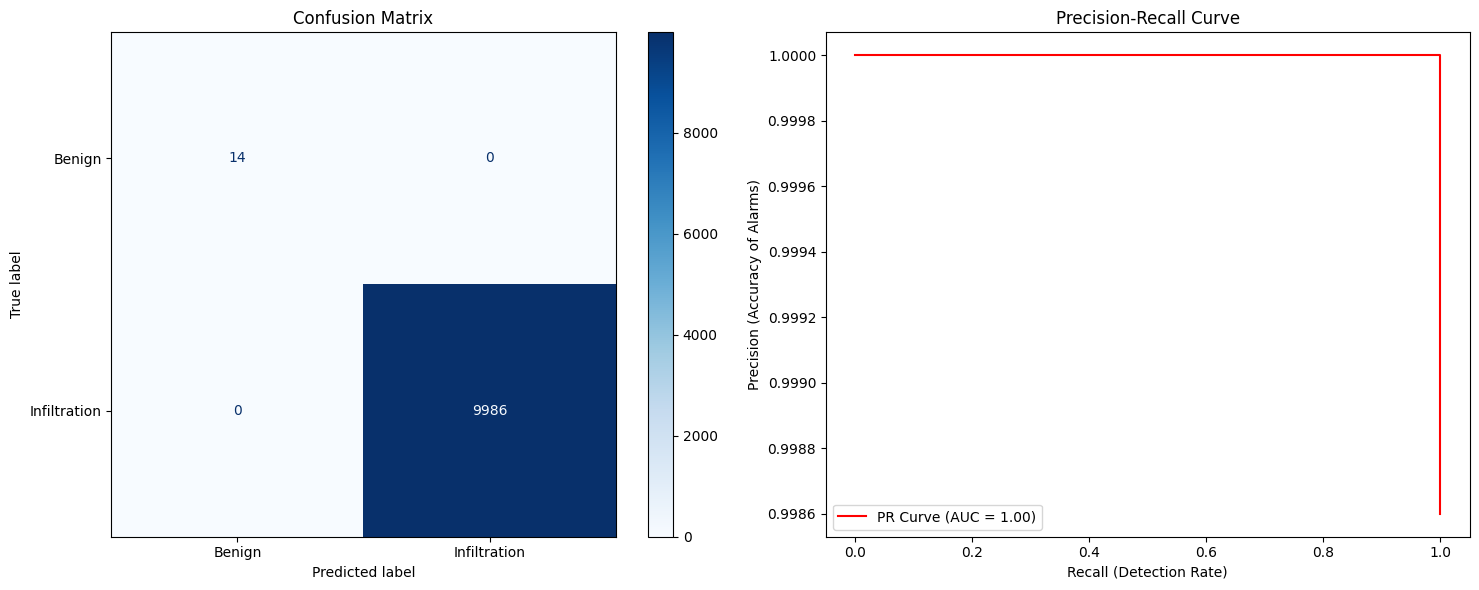

ValueError: 'facecolor' or 'color' argument must be a valid color orsequence of colors.

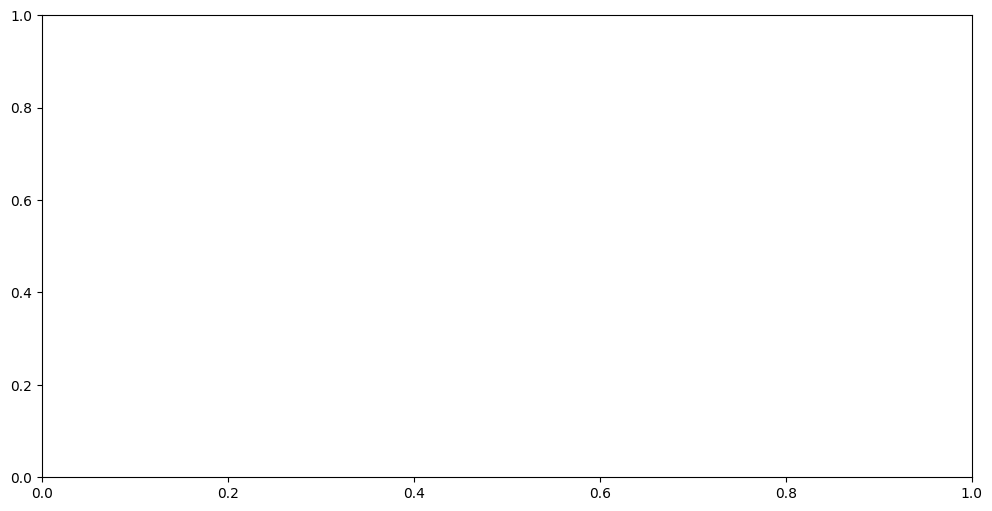

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils import class_weight

# --- Data Loading and Preprocessing ---
#1 Download a subset of the dataset (assuming 'traffic_data.csv' is available)

#2 Load the first 50,000 rows. This ensures we stay within Google Colab's free RAM limits while exceeding the 5,000 row requirement
df = pd.read_csv('traffic_data.csv', nrows=50000)

#3 Deep Cleaning: The 'Industry Standard' Routine
def clean_dataset(df):
  # Remove whitespace from column names
  df.columns = df.columns.str.strip()

  # Explicitly drop common non-numeric columns that might not be handled by to_numeric
  # Added 'Source Port', 'Destination Port', 'Protocol' as they can sometimes be object types
  cols_to_drop_if_exist = ['Timestamp', 'Flow ID', 'Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol']
  for col in cols_to_drop_if_exist:
      if col in df.columns:
          df = df.drop(col, axis=1)

  # Replace infinity or very large numbers with NaN, then drop them
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.dropna(inplace=True)

  # Convert all remaining columns to numeric, coercing errors to NaN
  # Exclude 'Label' from this conversion if it's the target and will be encoded separately
  feature_cols = [col for col in df.columns if col != 'Label']
  for col in feature_cols:
      df[col] = pd.to_numeric(df[col], errors='coerce')

  # Drop any NaNs that might have been introduced by pd.to_numeric
  df.dropna(inplace=True)

  # Drop columns that are constants (zero variance)
  df = df.loc[:, df.nunique() > 1]

  # Encode the 'Label' column to numerical values if it exists and is not numeric
  if 'Label' in df.columns and not pd.api.types.is_numeric_dtype(df['Label']):
      le = LabelEncoder()
      df['Label'] = le.fit_transform(df['Label'])
      print(f"Encoded 'Label' column to: {le.classes_}")
  elif 'Label' in df.columns and pd.api.types.is_numeric_dtype(df['Label']):
      # Ensure 'Label' is integer type if already numeric
      df['Label'] = df['Label'].astype(int)

  # Final step: ensure all feature columns are numeric.
  # This filters out any remaining object type columns that might have slipped through.
  if 'Label' in df.columns:
      label_series = df['Label']
      features_df = df.drop('Label', axis=1)
      numeric_features_only = features_df.select_dtypes(include=np.number)
      df = pd.concat([numeric_features_only, label_series], axis=1)
  else:
      df = df.select_dtypes(include=np.number) # If 'Label' was dropped or not present

  return df

df = clean_dataset(df)

# --- Data Splitting and Scaling ---
X_train, X_test, y_train, y_test = train_test_split(df.drop('Label', axis=1), df['Label'], test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Scale X_test using the same scaler fitted on X_train

# --- Model Definition ---
def build_ids_model (input_dim, num_classes):
  model = models.Sequential([
      # Input layer
      layers.Input(shape=(input_dim,)),

      # Hidden Layer 1: Capturing broad traffic patterns
      layers.Dense(128, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 2: Deepning the abstraction
      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.3),

      # Hidden Layer 3: Refining features
      layers.Dense(32, activation='relu'),

      # Output Layer: Softmax for multi-class or Sigmoid for binary
      # Corrected logic for binary classification output layer
      layers.Dense(num_classes if num_classes > 2 else 1, activation='softmax' if num_classes > 2 else 'sigmoid')
  ])

  model.compile (
      optimizer='adam',
      # Corrected loss function for binary vs multi-class
      loss='sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy',
      metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
  )
  return model

# Calculate class weights to handle 'Infiltration' rarity
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# Define Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_ids_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1

    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# Build and Summary
num_classes_in_y = len(np.unique(y_train))
model = build_ids_model(X_train.shape[1], num_classes_in_y)
model.summary()

# --- Model Training ---
print ("Starting training... monitoring Validation Loss to prevent overfitting. ")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

# --- Evaluation Implementation Code ---
# 1 Generate predictions
if num_classes_in_y > 2:
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1) # Get the class with the highest probability
else:
    y_pred_prob = model.predict(X_test).flatten() # Flatten for binary classification
    y_pred = (y_pred_prob > 0.5).astype(int) # Standard 0.5 threshold for binary

# 2 Detailed Classification Report
actual_labels = np.unique(y_test)
target_names = [f'Class_{label}' for label in actual_labels]
if num_classes_in_y == 2:
    target_names = ['Benign', 'Infiltration']

print ("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3 Plot Confusion Matrix
fig, ax = plt.subplots (1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions (y_test, y_pred,
                                         display_labels=target_names,
                                         cmap = 'Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4 Plot Precision-Recall Curve
if num_classes_in_y == 2:
    precision, recall, _ = precision_recall_curve (y_test, y_pred_prob)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='red')
    ax[1].set_xlabel('Recall (Detection Rate)')
    ax[1].set_ylabel('Precision (Accuracy of Alarms)')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].legend()
else:
    ax[1].set_title('Precision-Recall Curve (Not applicable for direct multi-class plot)')
    ax[1].text(0.5, 0.5, 'Requires one-vs-rest for multi-class', horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

# --- Comparison of 6 algorithms of confusion matrix ---
#1 Calculate the confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

#2 Calculate the professional metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = tn / (tn + fp) # true negative rate
fpr = fp / (fp + tn) # false positive rate

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity', 'False Positive Rate']
metrics_values = [accuracy, precision, recall, f1, specificity, fpr]

# Visualisation: Metric comparison graph
plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff70e', '#2ca02', '#d62728', '#9467bd', '#e377c2']
bars = plt.bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on top of bars
for bar in bars: # Corrected 'bars' to 'bar'
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1) # scale to 110% to fit labels
plt.title('Comprehensive Model Performance Profile: CSE-IDE-IDS2018', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print summary for the report
for name, value in zip(metrics_names, metrics_values):
  print(f"{name}: {value:.4f}") # Corrected 'val' to 'value' and removed extra colon
